# DT1_5 Profile Viewer

Interactive viewer for 1-D concentration profiles (mobile T + trapped T) exported by the simulation.

- **Dropdown** – select the bin file  
- **Slider + Prev/Next buttons** – navigate through timesteps  
- Left axis: mobile T concentration (m⁻³)  
- Right axis: per-trap and total trapped T concentration (m⁻³)

## 1 · Import libraries

In [1]:
import os
import json
import glob
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Use inline backend for notebook display
%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 110

## 2 · Load and parse all profile JSON files

In [2]:
PROFILES_DIR = "/home/ITER/llealsa/AdriaLlealS/PFC-Tritium-Transport/DT1_permeation/profiles_DT1_permeation"

def _get_trap_data_at(trap_dict, idx, n_x_mobile):
    """Return trap concentration array at timestep index `idx`.
    
    Trap data often has 2× the spatial resolution of mobile data due to how
    FESTIM exports DG0 functions.  We align it to the mobile x-grid by
    taking every other point (then trimming / padding to match length).
    """
    raw = np.array(trap_dict["data"][idx])
    if len(raw) == n_x_mobile:
        return raw
    # Down-sample: take every other sample
    down = raw[::2]
    if len(down) < n_x_mobile:
        down = np.pad(down, (0, n_x_mobile - len(down)), mode="edge")
    return down[:n_x_mobile]


# ----- scan directory and load all files -----
_pattern = os.path.join(PROFILES_DIR, "*.json")
_files = glob.glob(_pattern)

# Build a human-readable label from the filename
def _label(path):
    name = os.path.basename(path).replace("_profiles.json", "")
    # id_1_bin_num_0_w_highwetted  -->  bin 0 – highwetted (id 1)
    m = re.match(r"id_(\d+)_bin_num_(\d+)_w_(.*)", name)
    if m:
        return f"bin {m.group(2)} – {m.group(3)}  (id {m.group(1)})"
    return name

def _sort_key(path):
    """Sort by (bin_number, surface_type) so bin 0 always comes first."""
    name = os.path.basename(path)
    m = re.match(r"id_(\d+)_bin_num_(\d+)_w_(.*?)_profiles\.json", name)
    if m:
        return (int(m.group(2)), m.group(3))
    return (9999, name)

_files_sorted = sorted(_files, key=_sort_key)

ALL_DATA = {}   # label -> raw JSON dict
_skipped = []
for fp in _files_sorted:
    with open(fp) as fh:
        _d = json.load(fh)
    if "T_profile" not in _d:
        _skipped.append(os.path.basename(fp))
        continue
    ALL_DATA[_label(fp)] = _d

print(f"Loaded {len(ALL_DATA)} profile files.")
if _skipped:
    print(f"Skipped {len(_skipped)} file(s) without T_profile: {_skipped}")
print("First few labels:", list(ALL_DATA.keys())[:6])


Loaded 82 profile files.
First few labels: ['bin 0 – shadowed  (id 2)', 'bin 0 – wetted  (id 1)', 'bin 1 – shadowed  (id 4)', 'bin 1 – wetted  (id 3)', 'bin 2 – highwetted  (id 5)', 'bin 2 – lowwetted  (id 6)']


## 3 · Summary: bins and number of available timesteps

In [3]:
print(f"{'Bin label':<45}  {'#timesteps':>10}  {'t_min (s)':>12}  {'t_max (s)':>14}")
print("-" * 90)
for label, data in ALL_DATA.items():
    t = data["T_profile"]["t"]
    print(f"{label:<45}  {len(t):>10}  {t[0]:>12.1f}  {t[-1]:>14.1f}")

Bin label                                      #timesteps     t_min (s)       t_max (s)
------------------------------------------------------------------------------------------
bin 0 – shadowed  (id 2)                              654           0.0     220492743.6
bin 0 – wetted  (id 1)                                654           0.0     220492743.6
bin 1 – shadowed  (id 4)                              654           0.0     220492742.3
bin 1 – wetted  (id 3)                                654           0.0     220492743.6
bin 2 – highwetted  (id 5)                            654           0.0     220492743.6
bin 2 – lowwetted  (id 6)                             654           0.0     220492743.6
bin 2 – shadowed  (id 7)                              654           0.0     220492743.6
bin 3 – highwetted  (id 8)                            654           0.0     220492743.6
bin 3 – lowwetted  (id 9)                             654           0.0     220492742.3
bin 3 – shadowed  (id 10)    

## 4 · Core plotting function

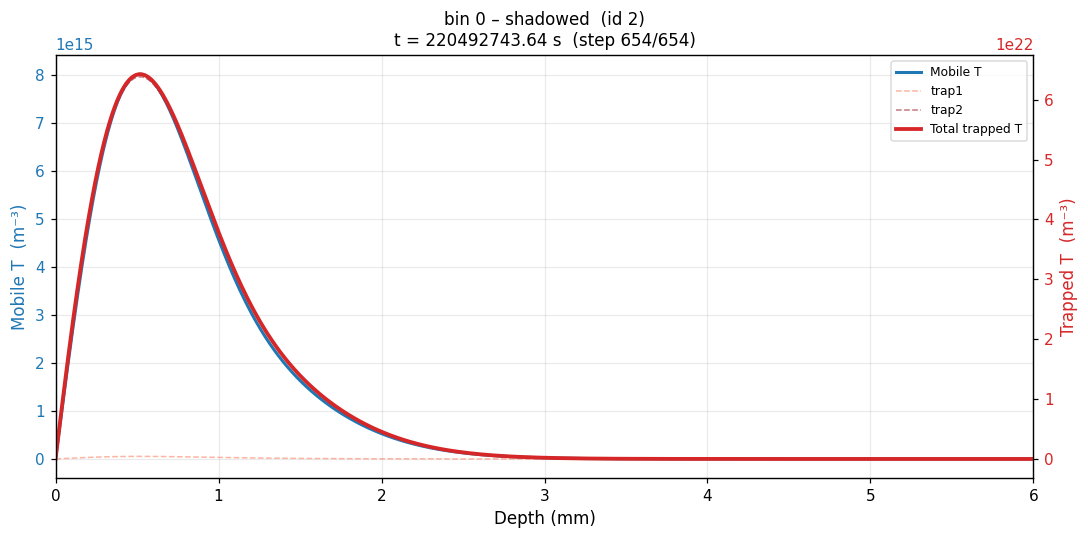

In [4]:
def plot_profile(bin_label: str, t_idx: int, ax1=None, ax2=None, close_after=False):
    """
    Plot mobile T (left axis) and trapped T (right axis) for a given
    bin_label and timestep index t_idx.

    If ax1/ax2 are None a new figure is created.
    Returns (fig, ax1, ax2).
    """
    data = ALL_DATA[bin_label]

    mobile = data["T_profile"]
    x     = np.array(mobile["x"]) * 1e3          # m → mm
    t_arr = np.array(mobile["t"])
    n_x   = len(x)
    t_val = t_arr[t_idx]

    # Trap T sub-dicts
    trap_keys = [k for k in data if k.endswith("_T_profile") and k.startswith("trap")]

    create_fig = (ax1 is None)
    if create_fig:
        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax2 = ax1.twinx()
    else:
        fig = ax1.get_figure()

    # ── Mobile T ───────────────────────────────────────────────────────────
    mob_vals = np.array(mobile["data"][t_idx])
    ax1.plot(x, mob_vals, color="tab:blue", linewidth=2,
             label=f"Mobile T")
    ax1.set_xlabel("Depth (mm)", fontsize=11)
    ax1.set_ylabel("Mobile T  (m⁻³)", color="tab:blue", fontsize=11)
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_xlim(x[0], x[-1])
    ax1.grid(True, alpha=0.25)

    # ── Trapped T ──────────────────────────────────────────────────────────
    trap_colors = plt.cm.Reds(np.linspace(0.45, 0.9, max(len(trap_keys), 1)))
    total_trapped = np.zeros(n_x)

    for i, tk in enumerate(trap_keys):
        trap_vals = _get_trap_data_at(data[tk], t_idx, n_x)
        short     = tk.replace("_T_profile", "")
        ax2.plot(x, trap_vals, color=trap_colors[i], linewidth=1,
                 alpha=0.55, linestyle="--", label=short)
        total_trapped += trap_vals

    if trap_keys:
        ax2.plot(x, total_trapped, color="tab:red", linewidth=2.5,
                 label="Total trapped T")
        ax2.set_ylabel("Trapped T  (m⁻³)", color="tab:red", fontsize=11)
        ax2.tick_params(axis="y", labelcolor="tab:red")

    # ── Legend ─────────────────────────────────────────────────────────────
    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labs1 + labs2, loc="best", fontsize=8,
               framealpha=0.7)

    n_t = len(t_arr)
    ax1.set_title(
        f"{bin_label}\n"
        f"t = {t_val:.2f} s  (step {t_idx + 1}/{n_t})",
        fontsize=11,
    )
    fig.tight_layout()

    if close_after:
        plt.close(fig)

    return fig, ax1, ax2


# Quick smoke-test with the first bin, last timestep
_first = list(ALL_DATA.keys())[0]
_n     = len(ALL_DATA[_first]["T_profile"]["t"])
fig, *_ = plot_profile(_first, _n - 1)
plt.show()

## 5 · Interactive viewer

Use the **dropdown** to pick a bin, then step through timesteps with the **slider** or the **◀ Prev / Next ▶** buttons.

In [5]:
ALL_LABELS = list(ALL_DATA.keys())

# ── Widgets ────────────────────────────────────────────────────────────────────
bin_dropdown = widgets.Dropdown(
    options=ALL_LABELS,
    value=ALL_LABELS[0],
    description="Bin:",
    layout=widgets.Layout(width="480px"),
    style={"description_width": "40px"},
)

def _n_steps(label):
    return len(ALL_DATA[label]["T_profile"]["t"])

t_slider = widgets.IntSlider(
    min=0,
    max=_n_steps(ALL_LABELS[0]) - 1,
    step=1,
    value=0,
    description="Step:",
    continuous_update=False,
    layout=widgets.Layout(width="480px"),
    style={"description_width": "40px"},
)

t_label = widgets.Label(value="")   # shows current time in seconds

btn_prev = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="90px"))
btn_next = widgets.Button(description="Next ▶", layout=widgets.Layout(width="90px"))

# ── Depth control ──────────────────────────────────────────────────────────────
# Max depth of the first bin (in mm) as default
_first_x_mm = np.array(ALL_DATA[ALL_LABELS[0]]["T_profile"]["x"]) * 1e3
_default_max_mm = float(_first_x_mm[-1])

depth_value = widgets.FloatText(
    value=round(_default_max_mm, 6),
    description="Max depth:",
    layout=widgets.Layout(width="200px"),
    style={"description_width": "75px"},
    step=0.001,
)

depth_unit = widgets.Dropdown(
    options=["mm", "µm", "nm"],
    value="mm",
    description="",
    layout=widgets.Layout(width="80px"),
)

# Convert display value → mm (internal unit)
def _depth_limit_mm():
    v = depth_value.value
    u = depth_unit.value
    if u == "nm":
        return v * 1e-6
    elif u == "µm":
        return v * 1e-3
    else:
        return v

# When the unit changes, convert the current value to the new unit
_prev_unit = {"val": "mm"}
def _on_unit_change(change):
    old_u = _prev_unit["val"]
    new_u = change["new"]
    v = depth_value.value
    # old → mm
    if old_u == "nm":
        v_mm = v * 1e-6
    elif old_u == "µm":
        v_mm = v * 1e-3
    else:
        v_mm = v
    # mm → new
    if new_u == "nm":
        depth_value.value = round(v_mm * 1e6, 3)
    elif new_u == "µm":
        depth_value.value = round(v_mm * 1e3, 3)
    else:
        depth_value.value = round(v_mm, 6)
    _prev_unit["val"] = new_u

depth_unit.observe(_on_unit_change, names="value")

btn_full = widgets.Button(description="Full range", layout=widgets.Layout(width="90px"))

def _on_full_range(_):
    """Reset depth to full range of current bin."""
    label = bin_dropdown.value
    x_mm = np.array(ALL_DATA[label]["T_profile"]["x"]) * 1e3
    max_mm = float(x_mm[-1])
    u = depth_unit.value
    if u == "nm":
        depth_value.value = round(max_mm * 1e6, 3)
    elif u == "µm":
        depth_value.value = round(max_mm * 1e3, 3)
    else:
        depth_value.value = round(max_mm, 6)

btn_full.on_click(_on_full_range)

out = widgets.Output()

# ── Callbacks ──────────────────────────────────────────────────────────────────
def _update_time_label():
    label = bin_dropdown.value
    idx   = t_slider.value
    t_val = ALL_DATA[label]["T_profile"]["t"][idx]
    n     = _n_steps(label)
    t_label.value = f"t = {t_val:.2f} s  ({idx + 1}/{n})"

def _redraw(*_):
    with out:
        clear_output(wait=True)
        fig, ax1, ax2 = plot_profile(bin_dropdown.value, t_slider.value)
        xlim = _depth_limit_mm()
        ax1.set_xlim(0, xlim)
        fig.tight_layout()
        plt.show()
    _update_time_label()

def _on_bin_change(change):
    # Reset slider range for new bin
    n = _n_steps(change["new"])
    t_slider.max   = n - 1
    t_slider.value = 0
    # Reset depth to full range of new bin
    _on_full_range(None)
    _redraw()

def _on_prev(_):
    if t_slider.value > t_slider.min:
        t_slider.value -= 1

def _on_next(_):
    if t_slider.value < t_slider.max:
        t_slider.value += 1

bin_dropdown.observe(_on_bin_change, names="value")
t_slider.observe(_redraw, names="value")
depth_value.observe(_redraw, names="value")
btn_prev.on_click(_on_prev)
btn_next.on_click(_on_next)

# ── Layout ─────────────────────────────────────────────────────────────────────
controls = widgets.VBox([
    bin_dropdown,
    widgets.HBox([btn_prev, t_slider, btn_next, t_label]),
    widgets.HBox([depth_value, depth_unit, btn_full]),
])

display(controls, out)

# Initial render
_redraw()

Output()

## 6 · (Optional) Batch-export all profiles to PNG

Run this cell to save every bin × timestep combination as a PNG file inside `plots_DT1_5/`.

In [6]:
EXPORT = False   # <-- set to True to actually run the export

if EXPORT:
    OUT_DIR = os.path.join(PROFILES_DIR, "..", "plots_DT1_5")
    os.makedirs(OUT_DIR, exist_ok=True)
    total = sum(_n_steps(lbl) for lbl in ALL_LABELS)
    done  = 0
    for label in ALL_LABELS:
        safe_label = re.sub(r"[^\w\-]", "_", label)
        n = _n_steps(label)
        for idx in range(n):
            fig, *_ = plot_profile(label, idx, close_after=True)
            fname = os.path.join(OUT_DIR, f"{safe_label}_step{idx:04d}.png")
            fig.savefig(fname, dpi=150, bbox_inches="tight")
            plt.close(fig)
            done += 1
        print(f"[{done}/{total}] {label} done ({n} steps)", end="\r")
    print(f"\nAll {total} plots saved to {OUT_DIR}")
else:
    print("Export disabled  (set EXPORT = True to run)")


Export disabled  (set EXPORT = True to run)
